# Chi-Square and F Distributions

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/eabarnes1010/course_objective_analysis/blob/main/code/chisquare_distribution.ipynb)

*Elizabeth A. Barnes — BU Earth & Environment — Last updated: 2026-05-21*

## Learning objectives

- See how the **chi-square distribution** arises from the ratio of a sample variance to a known population variance, and use it to test whether a sample's variance differs from an expected value.
- See how the **F-distribution** arises from the ratio of two sample variances, and use it to test whether two samples could share the same underlying variance.
- Build each distribution from a Monte Carlo simulation and confirm it matches the theoretical curve, then drop the Monte Carlo and use the theoretical distribution directly for hypothesis tests.

So far we have mainly dealt with the normal distribution, but there are a lot of other distributions out there. In this notebook we look at two of the most useful for hypothesis-testing about variances: the chi-square and the F-distribution.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Figure defaults for this notebook.
plt.rcParams["figure.dpi"] = 150
plt.rcParams["figure.figsize"] = (6.0, 4.0)

# Seeded random generator so the figures reproduce across runs.
rng = np.random.default_rng(seed=2026)

## Chi-square distribution

Start by making a large "bucket" of values that follow a standard normal — this will play the role of our known population.

In [2]:
sigma_pop = 1.0
mean_pop = 0.0

population = rng.normal(loc=mean_pop, scale=sigma_pop, size=100_000)

Now draw 10,000 samples of size $n=45$ from this population. For each sample, compute the statistic

$$\chi^2 \;=\; \frac{(n-1)\, s^2}{\sigma^2},$$

where $s^2$ is the *unbiased* sample variance (`np.var(..., ddof=1)`) and $\sigma^2$ is the known population variance. The $(n-1)$ factor and the unbiased estimator together make this statistic chi-square-distributed with $n-1$ degrees of freedom — we'll verify that empirically in a moment.

In [3]:
n_sample = 45
n_trials = 10_000

x2 = []
for _ in range(n_trials):
    sample = rng.choice(population, size=n_sample, replace=True)
    s_squared = np.var(sample, ddof=1)
    x2.append((n_sample - 1) * s_squared / sigma_pop**2)

Plot the histogram of our 10,000 $\chi^2$ values. (I like to guess the shape first — $\chi^2$ can't be negative, so I expect a distribution bounded at zero with a long right tail.)

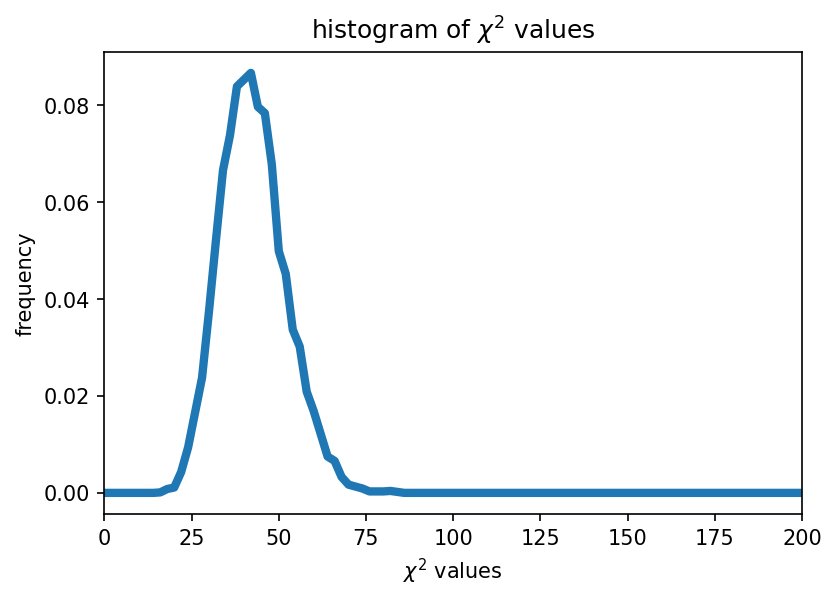

In [4]:
xbins = np.arange(0, 1000, 2)
hx, _ = np.histogram(x2, bins=xbins)

plt.figure()
plt.plot(xbins[:-1], hx / len(x2), linewidth=4)
plt.title(r"histogram of $\chi^2$ values")
plt.xlabel(r"$\chi^2$ values")
plt.ylabel("frequency")
plt.xlim(0, 200)
plt.show()

As predicted: bounded at zero, long right tail. This histogram is the empirical distribution of the ratio of a sample variance to the true variance — known analytically as the **chi-square distribution** with $n-1$ degrees of freedom. Let's overlay the theoretical chi-square to confirm.

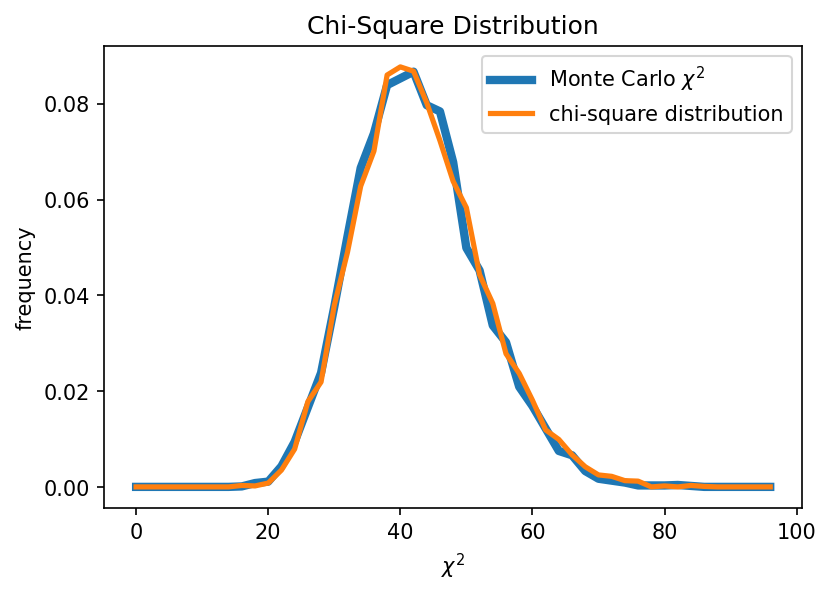

In [5]:
xbins = np.arange(0, 100, 2)
hx, _ = np.histogram(x2, bins=xbins)

chi_square_theory = rng.chisquare(n_sample - 1, size=n_trials)
hcs, _ = np.histogram(chi_square_theory, bins=xbins)

plt.figure()
plt.plot(xbins[:-1], hx / len(x2), linewidth=4, label=r"Monte Carlo $\chi^2$")
plt.plot(
    xbins[:-1],
    hcs / len(chi_square_theory),
    linewidth=2.5,
    label="chi-square distribution",
)
plt.title("Chi-Square Distribution")
plt.xlabel(r"$\chi^2$")
plt.ylabel("frequency")
plt.legend()
plt.show()

## Lecture example: has my sample variance changed?

Suppose we went out into the field and took some measurements. Our sample summary stats are below.

In [6]:
n_sample = 100
mu_sample = 10.0
std_sample = 1.5

We want to know whether the variance of our sample is different from what it "used to be". Suppose the population variance was once $\sigma^2 = 2.0$, so the population standard deviation was $\sigma = \sqrt{2.0} \approx 1.41$.

In [7]:
std_pop = np.sqrt(2.0)

Assuming the data still follows a normal distribution, we can use the chi-square distribution. We've already convinced ourselves (above) that the Monte Carlo $\chi^2$ matches the theoretical curve, so from here on we'll just use the theoretical distribution directly.

Compute the test statistic from our data:

In [8]:
x2_sample = (n_sample - 1) * std_sample**2 / std_pop**2
print(f"chi-square statistic = {x2_sample:.2f}")

chi-square statistic = 111.37


Is that value big or small? Compare it to the theoretical chi-square distribution with $n-1$ degrees of freedom — what we would expect under the null hypothesis that the variance has not changed.

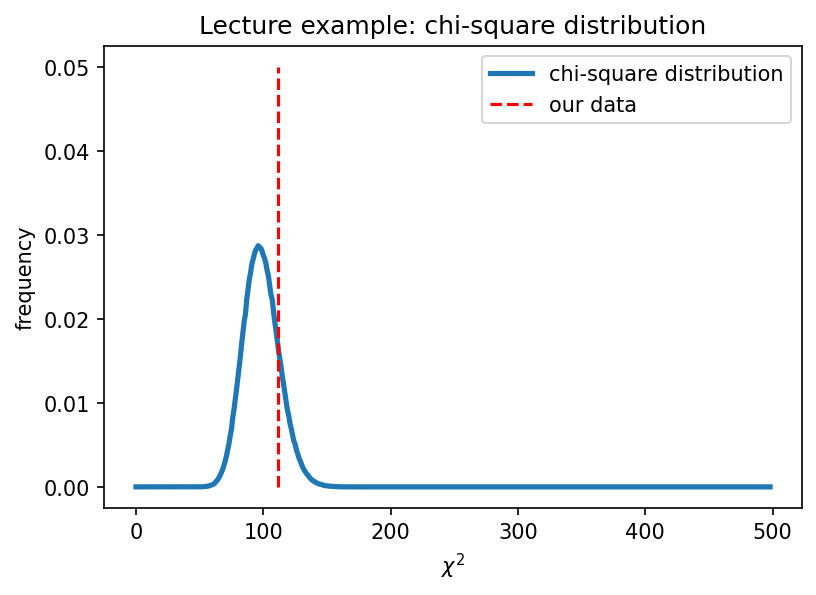

In [9]:
xbins = np.arange(0, 500, 1.0)
chi_square_theory = rng.chisquare(n_sample - 1, size=1_000_000)
hcs, _ = np.histogram(chi_square_theory, bins=xbins)

plt.figure()
plt.plot(
    xbins[:-1],
    hcs / len(chi_square_theory),
    linewidth=2.5,
    label="chi-square distribution",
)
plt.plot([x2_sample, x2_sample], [0, 0.05], "--r", label="our data")

plt.title("Lecture example: chi-square distribution")
plt.xlabel(r"$\chi^2$")
plt.ylabel("frequency")
plt.legend()
plt.show()

By eye, our test statistic sits comfortably inside the bulk of the chi-square distribution — it does not look extreme. We would *not* conclude that the variance has changed from this sample alone.

## F-distribution

While the chi-square is for the ratio of a sample variance to a *known* variance, the **F-statistic** is for the ratio of *two* sample variances. The setup: under the null hypothesis, two samples come from populations with the same variance. Build two normal "buckets" and see what the ratio of their sample variances looks like over many draws.

In [10]:
B1 = rng.normal(loc=0.0, scale=1.0, size=100_000)
B2 = rng.normal(loc=0.0, scale=1.0, size=100_000)

Draw samples of different sizes from each bucket, compute the *unbiased* sample variance of each (`ddof=1`), and take the ratio. Repeat 10,000 times.

In [11]:
n_sample_1 = 50
n_sample_2 = 25
n_trials = 10_000

F_mc = []
for _ in range(n_trials):
    sample1 = rng.choice(B1, size=n_sample_1, replace=True)
    sample2 = rng.choice(B2, size=n_sample_2, replace=True)
    s1_sq = np.var(sample1, ddof=1)
    s2_sq = np.var(sample2, ddof=1)
    F_mc.append(s1_sq / s2_sq)

Plot the distribution of these ratios.

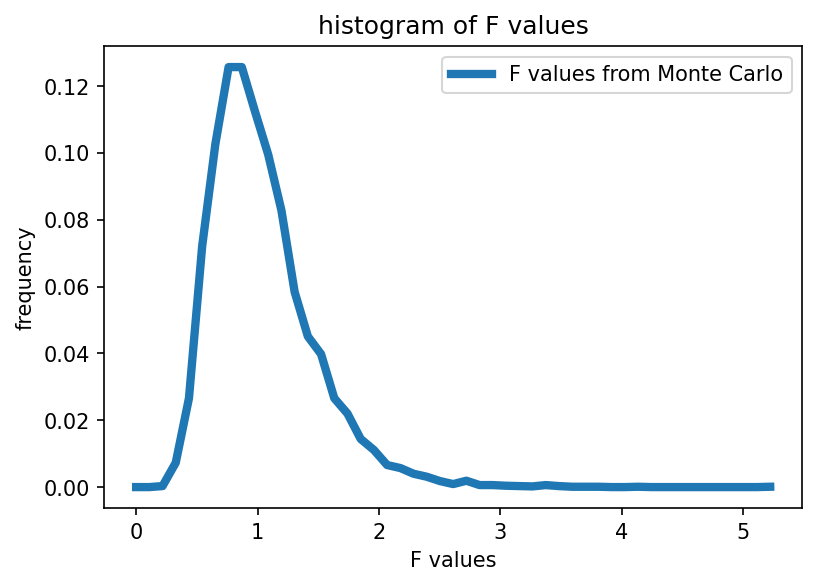

In [12]:
xbins = np.linspace(0, np.max(F_mc), 50)
hx, _ = np.histogram(F_mc, bins=xbins)

plt.figure()
plt.plot(xbins[:-1], hx / len(F_mc), linewidth=4, label="F values from Monte Carlo")
plt.title("histogram of F values")
plt.xlabel("F values")
plt.ylabel("frequency")
plt.legend()
plt.show()

This empirical distribution is also known analytically — it is the **F-distribution** with $(n_1 - 1, n_2 - 1)$ degrees of freedom. Overlay the theoretical curve to confirm.

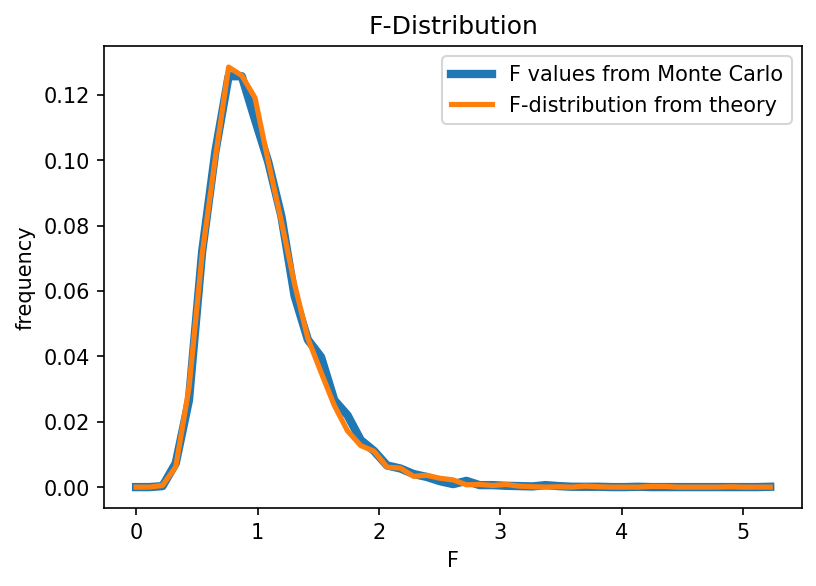

In [13]:
df_num = n_sample_1 - 1
df_den = n_sample_2 - 1

F_theory = rng.f(df_num, df_den, size=n_trials)
hF, _ = np.histogram(F_theory, bins=xbins)

plt.figure()
plt.plot(xbins[:-1], hx / len(F_mc), linewidth=4, label="F values from Monte Carlo")
plt.plot(
    xbins[:-1], hF / len(F_theory), linewidth=2.5, label="F-distribution from theory"
)
plt.title("F-Distribution")
plt.xlabel("F")
plt.ylabel("frequency")
plt.legend()
plt.show()

## Lecture example: are these two variances different?

Suppose we collect two samples of unequal length and compute the standard deviations of each. They come out different — are the differences *interesting*, or just sampling variability?

In [14]:
# sample 1
n_sample_1 = 50
s1 = 6

# sample 2
n_sample_2 = 25
s2 = 4

Our null hypothesis: both samples came from the same underlying normal population, so the underlying variances are equal. Compute the F-statistic from our data:

In [15]:
Fval = s1**2 / s2**2
print(f"F statistic = {Fval}")

F statistic = 2.25


So sample 1 has 2.25 times the variance of sample 2. Compare this against the theoretical F-distribution under the null:

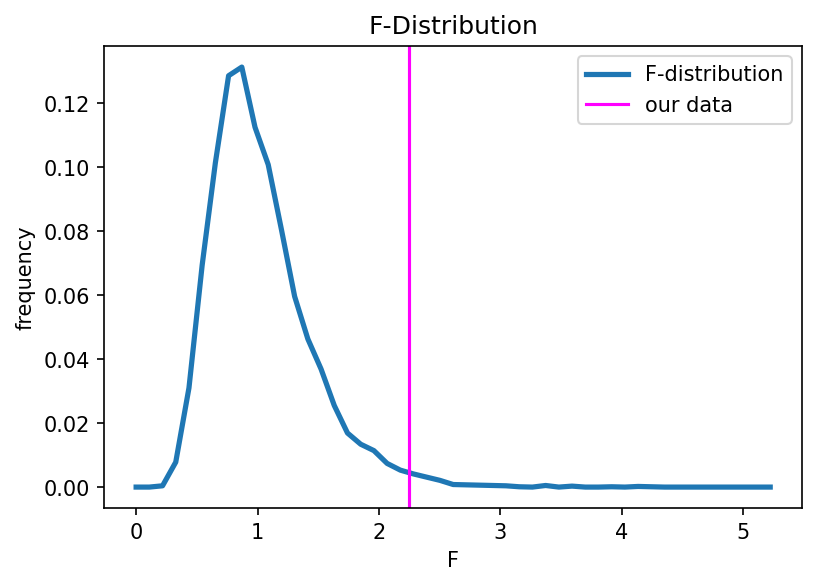

In [16]:
df_num = n_sample_1 - 1
df_den = n_sample_2 - 1

F_theory = rng.f(df_num, df_den, size=n_trials)
hF, _ = np.histogram(F_theory, bins=xbins)

plt.figure()
plt.plot(xbins[:-1], hF / len(F_theory), linewidth=2.5, label="F-distribution")
plt.axvline(x=Fval, linestyle="-", color="fuchsia", label="our data")
plt.title("F-Distribution")
plt.xlabel("F")
plt.ylabel("frequency")
plt.legend()
plt.show()

What is the probability of getting an F of 2.25 or higher under the null hypothesis that the two samples came from populations with equal variance?

In [17]:
p_value = 1 - stats.f.cdf(Fval, df_num, df_den)
print(f"P(F >= {Fval:.2f} | null) = {p_value:.4f}")

P(F >= 2.25 | null) = 0.0169


So roughly a 1.7% chance of seeing a ratio this large (or larger) under the null. That's small enough to be interesting — it suggests the two samples may genuinely have different underlying variances, and would prompt us to look further into *why*.

## Wrap-up

- The **chi-square distribution** describes the scaled sample variance of a normal sample. We used it to test whether a sample's variance differs from a known population variance.
- The **F-distribution** describes the ratio of two sample variances drawn from normal populations with equal variance. We used it to test whether two samples could plausibly share the same underlying variance.
- In both cases we first *built* the distribution from a Monte Carlo simulation, confirmed it matches the theoretical curve, and then used the theoretical distribution directly for the hypothesis test. The Monte Carlo is a teaching device; in practice you just call `scipy.stats.chi2` / `scipy.stats.f`.